### HITS アルゴリズム

In [1]:
### リスト1 ###

import networkx as nx

# 有向グラフの作成
G = nx.DiGraph()
G.add_edges_from([
    ('A', 'B'), ('A', 'C'),
    ('B', 'C'),
    ('C', 'A'),
    ('D', 'C')
])

# HITSアルゴリズムの計算
hubs, authorities = nx.hits(G)

# 指定した順番（A, B, C, D）で表示
nodes_order = ['A', 'B', 'C', 'D']

print("Hub Scores:")
for node in nodes_order:
    print(f"  {node}: {hubs[node]:.4f}")

print("\nAuthority Scores:")
for node in nodes_order:
    print(f"  {node}: {authorities[node]:.4f}")

Hub Scores:
  A: 0.4142
  B: 0.2929
  C: 0.0000
  D: 0.2929

Authority Scores:
  A: 0.0000
  B: 0.2929
  C: 0.7071
  D: -0.0000


### PageRankアルゴリズム

PageRank scores (アルファベット順):
Page A: 0.3725
Page B: 0.1958
Page C: 0.3942
Page D: 0.0375


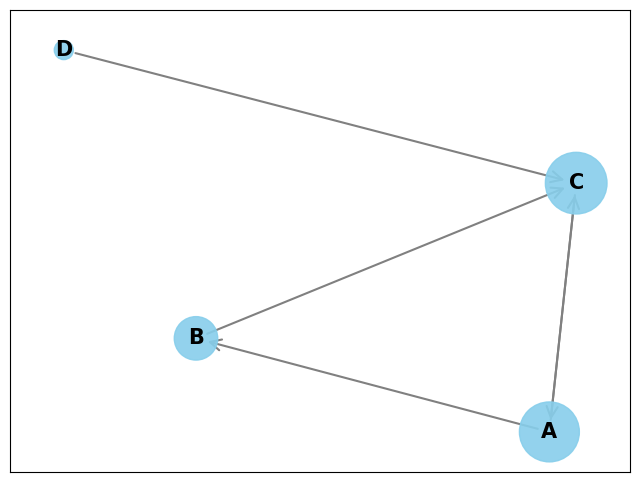

In [21]:
### リスト2 ###

import networkx as nx
import matplotlib.pyplot as plt

# 有向グラフの作成（アルファベットで定義）
G = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), 
         ('B', 'C'), 
         ('C', 'A'), 
         ('D', 'C')]
G.add_edges_from(edges)

# PageRankの計算
pagerank = nx.pagerank(G, alpha=0.85)

# 結果をアルファベット順に表示
print("PageRank scores (アルファベット順):")
for node in sorted(G.nodes()):
    print(f"Page {node}: {pagerank[node]:.4f}")

# 可視化
plt.figure(figsize=(8, 6))

# レイアウト（配置）の決定
#pos = nx.spring_layout(G, seed=42) 
pos = nx.spring_layout(G) 

# ノードの大きさをPageRankスコアに比例させる (スコア * 5000倍)
node_sizes = [pagerank[node] * 5000 for node in G.nodes()]

# 描画
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif', font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5)

#plt.axis('off') # 座標軸を非表示
plt.show()